#### K-Nearest Neighbors

It is one of the supervised machine learning algorithm that helps in finding out the category for the test data based on the n number of nearest neighbors.

#### Goal of K-Nearest Neighbors

1.  The main aim of this project is to find out the category of the particular Iris Plant species data using KNN Algorithm .

2.  Then we can even improve the accuracy of the model using Hyper Parameter Tuning for Grid Search CV.

#### Step 1:    Import  all the necessary libraries

In [1943]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.datasets         import  load_iris
from    sklearn.model_selection  import  train_test_split, GridSearchCV, StratifiedKFold
from    sklearn.preprocessing    import  StandardScaler
from    sklearn.neighbors        import  KNeighborsClassifier
from    sklearn.metrics          import  accuracy_score, confusion_matrix, classification_report, recall_score, precision_score

#### Step 2: Load the Dataset

In [1944]:
#### Obtain the data from the dataset

data = load_iris()

#### Construct the dataframe from the data

df = pd.DataFrame(data.data, columns=data.feature_names)


#### Adding the target to the dataset

df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [1945]:
df[df["target"] == 2]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2
105,7.6,3.0,6.6,2.1,2
106,4.9,2.5,4.5,1.7,2
107,7.3,2.9,6.3,1.8,2
108,6.7,2.5,5.8,1.8,2
109,7.2,3.6,6.1,2.5,2


#### OBSERVATIONS:

1.  The above dataset explains about the details for all the Iris plants.

2.  The inputs for the dataset are the sepal_length , sepal_width, petal_length, petal_width.

3.  The output of the dataset is the target that explains about the type of the Iris Plant Species whether it is having setosa/ versicolor / virginica.

#### Step 3: Perform the Data Exploration

In [1946]:
#### get the top five records of the dataset

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [1947]:
#### get the bottom five records of the dataset

df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [1948]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 150


In [1949]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (150, 5)


In [1950]:
#### get the columns used in the dataset

df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [1951]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


####  OBSERVATIONS:

1.  All the inputs are floating in nature like petal_length, petal_width, sepal_length, sepla_width

2.  The target defines the type of the Iris Plant Species and it is integer in nature.

In [1952]:
#### get the descriptive summary statistics about the column used in the dataset

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


#### OBSERVATIONS:

1.  The above dataset explains about the statistical information about each numerical column in the dataset.

In [1953]:
#### get the correlation between all the columns in the dataset

df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


<Axes: >

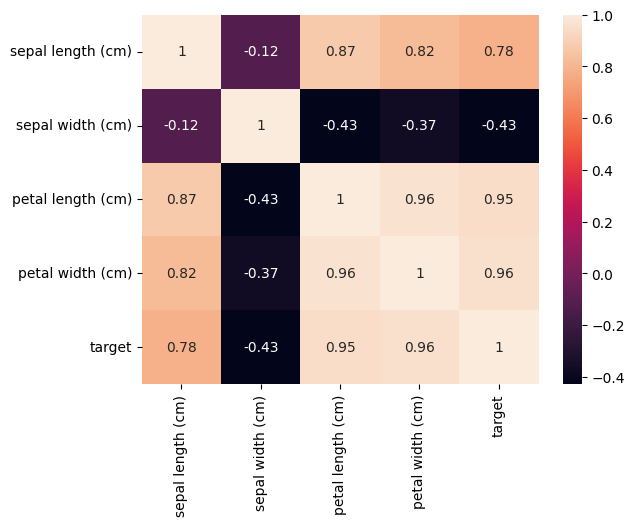

In [1954]:
#### get the graphical representation between all the columns in the dataset

sns.heatmap(df.corr(),annot=True)

#### Step 4: Perform Data Cleaning and Feature Engineering

In [1955]:
#### To check for the NULL records in the dataset

df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL Values in the dataset.

In [1956]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2


#### OBSERVATIONS:

1.  There is only one duplicate record. So remove it.

In [1957]:
#### Remove the duplicate record from the dataset

df = df.drop_duplicates()

In [1958]:
#### To again check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [1959]:
#### Reanme all the columns in the dataset

df.rename(columns={
"sepal length (cm)":"sepal_length",
"sepal width (cm)" :"sepal_width" ,
"petal length (cm)":"petal_length",
"petal width (cm)" :"petal_width"},inplace=True)

In [1960]:
#### Again check the dataframe

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### OBSERVATIONS:

1.  Now all the columns have been renamed to their proper names.

In [1961]:
#### Again check the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 149


#### OBSERVATIONS:

1. After removing the duplicate record from the dataset, the length of the dataset has reduced from 150 to 149.

#### Step 5: Divide the dataset into independent and dependent features

In [1962]:
#### independent features

X = df.drop(columns='target',axis=1)

print(X)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[149 rows x 4 columns]


In [1963]:
#### dependent features

Y = df['target']

print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 149, dtype: int64


#### Step 6: Divide the independent and dependent features into training and testing data

In [1964]:
from  sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [1965]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
6,4.6,3.4,1.4,0.3
128,6.4,2.8,5.6,2.1
95,5.7,3.0,4.2,1.2
44,5.1,3.8,1.9,0.4
30,4.8,3.1,1.6,0.2
...,...,...,...,...
52,6.9,3.1,4.9,1.5
47,4.6,3.2,1.4,0.2
102,7.1,3.0,5.9,2.1
124,6.7,3.3,5.7,2.1


In [1966]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
69,5.6,2.5,3.9,1.1
66,5.6,3.0,4.5,1.5
141,6.9,3.1,5.1,2.3
7,5.0,3.4,1.5,0.2
147,6.5,3.0,5.2,2.0
57,4.9,2.4,3.3,1.0
84,5.4,3.0,4.5,1.5
28,5.2,3.4,1.4,0.2
138,6.0,3.0,4.8,1.8
127,6.1,3.0,4.9,1.8


In [1967]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (119, 4)
Shape of the input testing  data is: (30, 4)


In [1968]:
Y_train

6      0
128    2
95     1
44     0
30     0
      ..
52     1
47     0
102    2
124    2
16     0
Name: target, Length: 119, dtype: int64

In [1969]:
Y_test

69     1
66     1
141    2
7      0
147    2
57     1
84     1
28     0
138    2
127    2
20     0
42     0
18     0
93     1
140    2
22     0
77     1
14     0
107    2
38     0
63     1
134    2
41     0
10     0
96     1
51     1
104    2
116    2
132    2
56     1
Name: target, dtype: int64

In [1970]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (119,)
Shape of the output testing  data is: (30,)


#### Step 7: Perform Feature Scaling on the inputs

In [1971]:
from  sklearn.preprocessing import StandardScaler

##### create an object for Standard Scaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

In [1972]:
X_train_scaled

array([[-1.50158712,  0.7690314 , -1.33909259, -1.17973677],
       [ 0.63982407, -0.58674247,  1.04183404,  1.1863645 ],
       [-0.19294695, -0.13481785,  0.24819183,  0.00331387],
       [-0.90675068,  1.67288064, -1.05564894, -1.0482867 ],
       [-1.26365254,  0.09114446, -1.22571513, -1.31118684],
       [-0.43088152, -1.49059172,  0.02143691, -0.1281362 ],
       [ 0.63982407, -0.81270478,  0.87176786,  0.92346436],
       [ 0.52085678,  0.54306908,  1.26858896,  1.71216479],
       [ 2.18639882, -0.58674247,  1.66541007,  1.05491443],
       [ 1.59156238, -0.13481785,  1.1552115 ,  0.52911415],
       [-0.19294695,  3.02865451, -1.28240386, -1.0482867 ],
       [ 0.52085678, -0.36078016,  1.04183404,  0.79201429],
       [ 0.99672594,  0.54306908,  1.09852277,  1.71216479],
       [ 0.52085678, -0.58674247,  0.7583904 ,  0.39766408],
       [-0.43088152,  2.57672988, -1.33909259, -1.31118684],
       [ 0.87775865, -0.36078016,  0.47494675,  0.13476394],
       [-0.43088152, -1.

In [1973]:
X_test_scaled

array([[-0.31191424, -1.26462941,  0.07812564, -0.1281362 ],
       [-0.31191424, -0.13481785,  0.41825802,  0.39766408],
       [ 1.23466052,  0.09114446,  0.7583904 ,  1.44926464],
       [-1.02571797,  0.7690314 , -1.28240386, -1.31118684],
       [ 0.75879136, -0.13481785,  0.81507913,  1.05491443],
       [-1.14468525, -1.49059172, -0.26200673, -0.25958627],
       [-0.54984881, -0.13481785,  0.41825802,  0.39766408],
       [-0.78778339,  0.7690314 , -1.33909259, -1.31118684],
       [ 0.16395492, -0.13481785,  0.58832421,  0.79201429],
       [ 0.28292221, -0.13481785,  0.64501294,  0.79201429],
       [-0.54984881,  0.7690314 , -1.1690264 , -1.31118684],
       [-1.7395217 ,  0.31710677, -1.39578132, -1.31118684],
       [-0.19294695,  1.67288064, -1.1690264 , -1.17973677],
       [-1.02571797, -1.71655403, -0.26200673, -0.25958627],
       [ 0.99672594,  0.09114446,  1.04183404,  1.58071472],
       [-1.50158712,  1.22095602, -1.56584751, -1.31118684],
       [ 0.99672594, -0.

#### OBSERVATIONS:

1.  After performing feature scaling on the inputs, all the inputs have been scaled in the same scale range between -1 to 1.

#### Step 8: Train the KNN Model

In [1974]:
from  sklearn.neighbors import KNeighborsClassifier

#### create an object for KNN

knn = KNeighborsClassifier(n_neighbors=3)

#### using the object for knn, train the model

knn.fit(X_train_scaled, Y_train)

KNeighborsClassifier(n_neighbors=3)

#### Step 9: Predict the KNN Model

In [1975]:
Y_pred = knn.predict(X_test_scaled)

In [1976]:
Y_pred

array([1, 1, 2, 0, 2, 1, 1, 0, 1, 2, 0, 0, 0, 1, 2, 0, 1, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1])

#### Step 10: Evaluate the Classification Metrics

In [1977]:
from    sklearn.metrics          import  accuracy_score, confusion_matrix, classification_report, recall_score, precision_score

print("====================================Accuracy Score==================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0
print("Accuracy score of the model is:", ac)


print("====================================Confusion Matrix==================================================")

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix of the model is:", cm)


print("====================================Classification Report==================================================")

cr = classification_report(Y_test, Y_pred)
print("Classification Report of the model is:", cr)


====================================Accuracy Score==================================================
Accuracy score of the model is: 93.33333333333333
====================================Confusion Matrix==================================================
Confusion Matrix of the model is: [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
====================================Classification Report==================================================
Classification Report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



#### OBSERVATIONS:

1.  The accuracy of the KNN Model is 93.33 which is high. So the model is working fine.

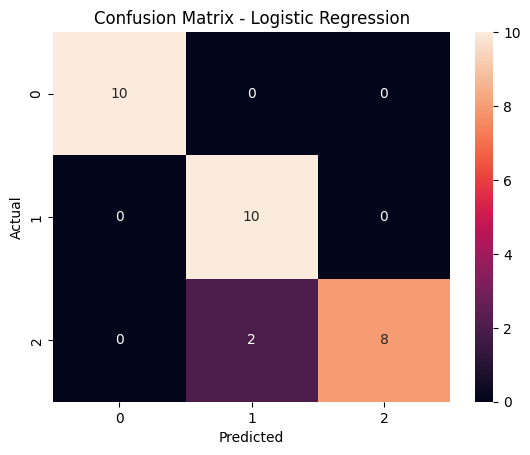

In [1978]:
#### Visualize the Confusion Matrix

import  seaborn  as  sns

sns.heatmap(cm, annot=True)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

#### Step 11: Predict the Type of the Iris Species on the test data

In [1979]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

#### perform the feature scaling on the inputs

scaled_inputs = sc.transform(sample)

print(scaled_inputs)


##### perform the predictions on the scaled data

predictions = knn.predict(scaled_inputs)

print(predictions)

if(predictions[0] == 0):
    print("setosa")
elif(predictions[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[[-0.90675068  0.99499371 -1.33909259 -1.31118684]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1980]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

#### perform the feature scaling on the inputs

scaled_inputs = sc.transform(sample)

print(scaled_inputs)


##### perform the predictions on the scaled data

predictions = knn.predict(scaled_inputs)

print(predictions)

if(predictions[0] == 0):
    print("setosa")
elif(predictions[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[[1.3536278  0.31710677 0.53163548 0.26621401]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1981]:
sample = np.array([[6.3, 3.3, 6.0, 2.5]])    

print(sample)

#### perform the feature scaling on the inputs

scaled_inputs = sc.transform(sample)

print(scaled_inputs)


##### perform the predictions on the scaled data

predictions = knn.predict(scaled_inputs)

print(predictions)

if(predictions[0] == 0):
    print("setosa")
elif(predictions[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[[0.52085678 0.54306908 1.26858896 1.71216479]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Step 12: Perform Hyper Parameter Tuning using GridSearchCV

In [1982]:
#### Define the pipeline

from sklearn.pipeline  import  Pipeline

pipeline = Pipeline([
    ("sc"   ,   StandardScaler())                  ,
    ("knn"  ,   KNeighborsClassifier())
])

In [1983]:
#### Define the parameter grid

param_grid = {
    "knn__n_neighbors"   :   list(range(1,21))
}

In [1984]:
#### Peform the Cross Validation

cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [1985]:
#### define the object for GridSearchCV

grid = GridSearchCV(
    pipeline                                ,
    param_grid       =        param_grid    ,
    cv               =          cv          ,
    scoring          =        'accuracy'    ,
    n_jobs           =          -1          
)

In [1986]:
#### train the GridSerachCV Model

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20]},
             scoring='accuracy')

In [1987]:
#### get the best parameters and the estimators of the model


best_parameters = grid.best_params_

print("Best Parameters of the model is:", best_parameters)


best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Parameters of the model is: {'knn__n_neighbors': 3}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=3))])


In [1988]:
#### Predict the GridSearchCV Model

Y_pred_grid = best_estimator.predict(X_test)

In [1989]:
Y_pred_grid

array([1, 1, 2, 0, 2, 1, 1, 0, 1, 2, 0, 0, 0, 1, 2, 0, 1, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1])

In [1990]:
#### Evaluate the Classification Metrics

from    sklearn.metrics          import  accuracy_score, confusion_matrix, classification_report, recall_score, precision_score

print("====================================Accuracy Score==================================================")

ac = accuracy_score(Y_test, Y_pred_grid)*100.0
print("Accuracy score of the model is:", ac)


print("====================================Confusion Matrix==================================================")

cm = confusion_matrix(Y_test, Y_pred_grid)
print("Confusion Matrix of the model is:", cm)


print("====================================Classification Report==================================================")

cr = classification_report(Y_test, Y_pred_grid)
print("Classification Report of the model is:", cr)

====================================Accuracy Score==================================================
Accuracy score of the model is: 93.33333333333333
====================================Confusion Matrix==================================================
Confusion Matrix of the model is: [[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]
====================================Classification Report==================================================
Classification Report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



#### OBSERVATIONS:

1.  The accuracy of KNN Model is still 93.33 even after performing the hyper parameter tuning using GridSearch CV operation.

#### Step 13: Predict the type of the Iris Species based on the test data

In [1991]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

##### perform the predictions on the scaled data

predictions = best_estimator.predict(sample)

print(predictions)

if(predictions[0] == 0):
    print("setosa")
elif(predictions[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1992]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

##### perform the predictions on the scaled data

predictions = best_estimator.predict(sample)

print(predictions)

if(predictions[0] == 0):
    print("setosa")
elif(predictions[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1993]:
sample = np.array([[6.3,	3.3,	6.0,	2.5]])    

print(sample)

##### perform the predictions on the scaled data

predictions = best_estimator.predict(sample)

print(predictions)

if(predictions[0] == 0):
    print("setosa")
elif(predictions[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
